# Train model

In [33]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model_asia'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [34]:
filename = os.path.join(context['portfolio_dir'], hayai_util.FILE_FEATURES)
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(227215, 59)

## EDA

In [35]:
df.describe()

c:\Users\semboli\Documents\progetti\hayai\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,AUDUSD,BZ,CNYUSD,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,...,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000,227215.000000
mean,0.656596,75.315518,0.139653,1.108653,1.295283,2921.407858,0.595602,1.376441,0.854572,149.709939,...,-0.081898,602.307084,-0.040283,0.086766,0.103549,0.873148,0.920351,1.027919,0.015627,-0.150878
std,0.019493,8.933862,0.002151,0.044403,0.041937,907.832068,0.018080,0.028734,0.044558,5.634527,...,1.466688,345.745461,0.230578,0.081454,0.093441,0.283205,0.424099,1.249844,1.050001,1.262396
min,0.595529,58.919998,0.136054,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,...,-5.000000,0.000000,-0.751977,0.001401,0.001758,0.227636,0.168764,0.000000,-1.444365,-2.630236
25%,0.644712,67.730003,0.137994,1.077389,1.262738,2081.899902,0.582469,1.357920,0.805900,145.927994,...,-0.765979,316.000000,-0.139972,0.037647,0.047536,0.664970,0.616968,0.373362,-0.598997,-1.122683
50%,0.655350,74.639999,0.139295,1.094296,1.288328,2657.600098,0.596210,1.371530,0.867110,149.451996,...,-0.097636,619.000000,-0.032250,0.062115,0.076178,0.890660,0.857647,0.714874,-0.288117,-0.321953
75%,0.667080,81.959999,0.140696,1.157756,1.336005,3373.500000,0.609240,1.391280,0.893930,154.617004,...,0.565336,879.000000,0.057093,0.104036,0.123642,1.097382,1.156489,1.171024,0.260315,0.788398
max,0.712921,112.190002,0.146180,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,...,5.000000,1250.000000,0.759662,0.482714,0.557106,1.387627,2.205683,8.394452,3.997162,2.903524


In [36]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 227215 entries, 472 to 357287
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   AUDUSD                         227215 non-null  float64
 1   BZ                             227215 non-null  float64
 2   CNYUSD                         227215 non-null  float64
 3   EURUSD                         227215 non-null  float64
 4   GBPUSD                         227215 non-null  float64
 5   GC                             227215 non-null  float64
 6   NZDUSD                         227215 non-null  float64
 7   USDCAD                         227215 non-null  float64
 8   USDCHF                         227215 non-null  float64
 9   USDJPY                         227215 non-null  float64
 10  ^DJI                           227215 non-null  float64
 11  ^GSPC                          227215 non-null  float64
 12  ^IXIC                          227215 non-nu

In [37]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

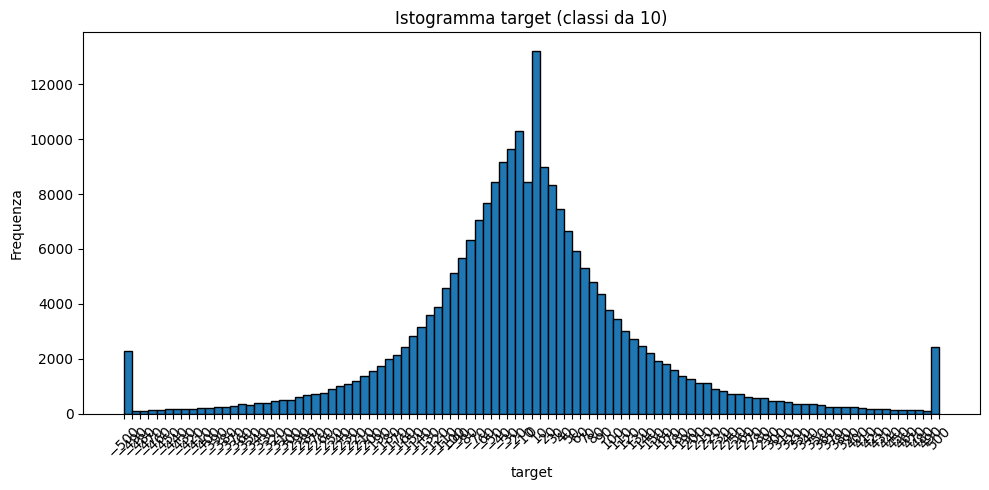

In [38]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

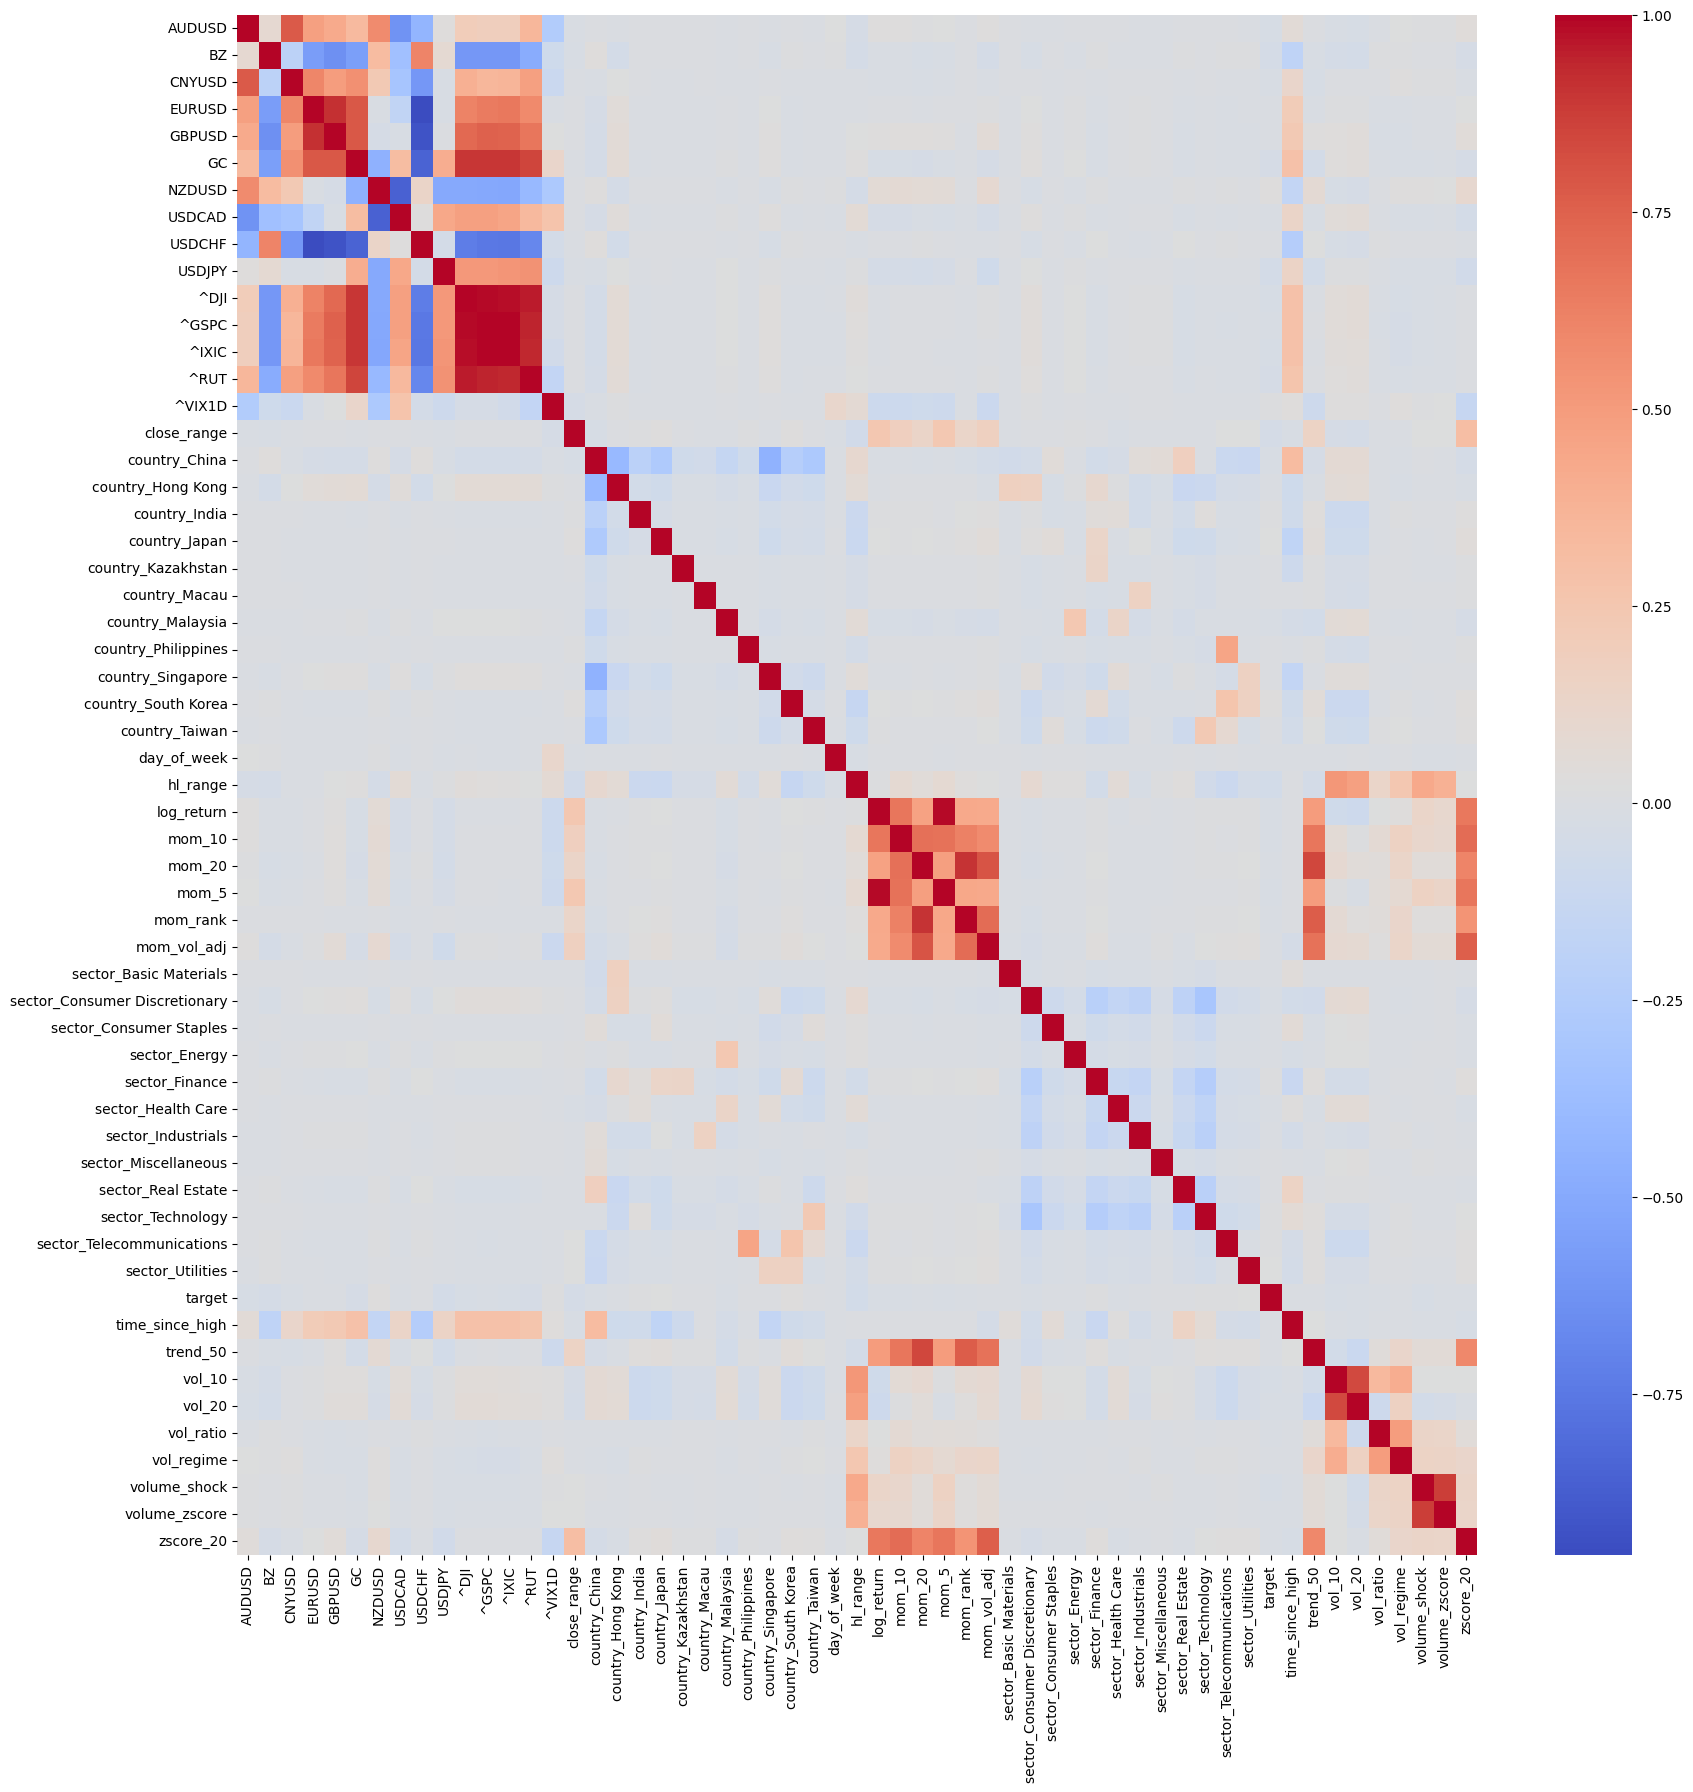

In [39]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [40]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

## Model building

In [41]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [42]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (227215,)
Data Shape: (227215, 56)
Train Data Shape: (181772, 56)
Train Labels Shape: (181772,)
Test Data Shape: (45443, 56)
Test Labels Shape: (45443,)


In [43]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         5,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,421 (60.24 KB)

 Trainable params: 15,421 (60.24 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/20
2273/2273 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 2/20
2273/2273 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 3/20
2273/2273 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 4/20
2273/2273 - 2s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 5/20
2273/2273 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 6/20
2273/2273 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 7/20
2273/2273 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 8/20
2273/2273 - 4s - 2ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 9/20
2273/2273 - 3s - 2ms/step - loss: 0.0215 - val_loss: 0.0213
Epoch 10/20
2273/2273 - 6s - 3ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 11/20
2273/2273 - 4s - 2ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 12/20
2273/2273 - 5s - 2ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 13/20
2273/2273 - 7s - 3ms/step - loss: 0.0215 - val_loss: 0.0212
Epoch 14/20
2273/2273 - 7s - 3ms/step - loss: 0.0215 - val_loss: 0.0212
E

Model saved to: data\model_asia\model.keras


In [45]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.49357018 0.49357018
Label: -0.7258, Prediction: -0.0643
Label: -5.0000, Prediction: -0.0643
Label: -4.7422, Prediction: -0.0643
Label: -1.1295, Prediction: -0.0643
Label: -2.3563, Prediction: -0.0643
Label: -0.2601, Prediction: -0.0643
Label: 1.2130, Prediction: -0.0643
Label: 0.4000, Prediction: -0.0643
Label: 2.6469, Prediction: -0.0643
Label: -1.7074, Prediction: -0.0643
Label: -0.3913, Prediction: -0.0643
Label: -1.5702, Prediction: -0.0643
Label: 0.4752, Prediction: -0.0643
Label: 5.0000, Prediction: -0.0643
Label: 2.6363, Prediction: -0.0643
Label: -0.1491, Prediction: -0.0643
Label: -1.8939, Prediction: -0.0643
Label: -5.0000, Prediction: -0.0643
Label: -0.5913, Prediction: -0.0643
Label: -3.5213, Prediction: -0.0643
Label: -1.5593, Prediction: -0.0643
Label: -0.3175, Prediction: -0.0643
Label: -1.1634, Prediction: -0.0643
Label: -0.2700, Prediction: -0.0643
Label: -0.6622, Prediction: -0.0643
Label: 2.3354, Prediction: -0.0643
Label: -1.7287, Predi

c:\Users\semboli\Documents\progetti\hayai\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\semboli\Documents\progetti\hayai\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
